# Change-detection session summary

Loads the two tables produced by `summarize_sessions.py`:

- **`session_metrics.csv`** — one row per session: identifying metadata + behavioral metrics (licks, rewards, changes/omissions, trial outcomes, performance, running speed).
- **`session_task_parameters.csv`** — one row per session: identifying metadata + every task parameter.

Then shows a handful of diagnostic plots across sessions.

In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Find the summaries dir relative to this notebook (code/ -> ../summaries),
# falling back to a few common locations.
_candidates = [
    Path.cwd().parent / 'summaries',
    Path.cwd() / 'summaries',
    Path('/root/capsule/summaries'),
    Path.cwd().parent / 'scratch',
    Path('/scratch'),
    Path('/results'),
]
SUMMARY_DIR = next(
    (p for p in _candidates if (p / 'session_metrics.csv').exists()), None)
if SUMMARY_DIR is None:
    raise FileNotFoundError(
        'session_metrics.csv not found. Run `python summarize_sessions.py` first.')
print('Loading summaries from:', SUMMARY_DIR)

metrics = pd.read_csv(SUMMARY_DIR / 'session_metrics.csv',
                      parse_dates=['acquisition_date'])
params = pd.read_csv(SUMMARY_DIR / 'session_task_parameters.csv',
                     parse_dates=['acquisition_date'])

# Order chronologically and build a compact per-session label for plots.
metrics = metrics.sort_values('acquisition_date').reset_index(drop=True)
params = params.sort_values('acquisition_date').reset_index(drop=True)
metrics['label'] = (metrics['acquisition_date'].dt.strftime('%Y-%m-%d')
                    + '  ' + metrics['session_type'].astype(str))
labels = metrics['label'].tolist()
x = np.arange(len(metrics))
print(f'{len(metrics)} sessions, subjects: '
      f"{sorted(metrics['subject_id'].unique())}")

Loading summaries from: /root/capsule/summaries
21 sessions, subjects: [np.int64(523922), np.int64(790322), np.int64(804670)]


## Session metrics table

In [13]:
metrics

,session_id,asset_name,subject_id,acquisition_date,session_type,session_description,stimulus_class,image_set_name,species,sex,age,genotype,institution,lab,experimenter,identifier,n_licks,n_rewards,n_image_changes,n_image_omissions,total_reward_volume_ml,n_earned_rewards,n_auto_rewards,n_lick_hit,n_lick_false_alarm,n_lick_abort,n_lick_early,n_lick_late,n_lick_consumption,n_lick_spontaneous,n_lick_bouts,n_trials,n_go,n_catch,n_auto_rewarded,n_aborted,n_hit,n_miss,n_false_alarm,n_correct_reject,n_warm_up,hit_rate,false_alarm_rate,dprime,mean_hit_response_latency_sec,session_duration_min,n_stimulus_presentations,n_omitted_flashes,n_change_flashes,running_speed_mean,running_speed_std,running_speed_median,running_speed_max,label
0,1050231786,old_vbo_data,523922,2020-09-14 10:11:13.692000+00:00,OPHYS_3_images_A,OPHYS_3_images_A,images,Natural_Images_Lum_Matched_set_training_2017.0...,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,87fea140-d65b-4fb2-b2c2-656e2d43f13f,2217,97,274,187,0.669,92,5,93,260,519,4,138,947,256,472,631,269,86,13,318,92,177,1,38,5,0.342007,0.025641,1.375067,0.512471,60.043228,4799,187,274,29.385763,19.900306,32.898773,78.052448,2020-09-14 OPHYS_3_images_A
1,1442075303,multiplane-ophys_790322_2025-06-11_15-09-29,790322,2025-06-11 15:09:28.880000+00:00,TRAINING_0_gratings_autorewards_15min,TRAINING_0_gratings_autorewards_15min,grating,NaN,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,c6bb1ff3-5a63-4622-84d6-8a3fa0085ef4,1684,122,122,0,0.610,0,122,0,0,0,0,0,1157,527,383,122,0,0,122,0,0,0,0,0,0,NaN,NaN,NaN,NaN,15.092251,123,0,122,0.054292,2.247987,0.000072,20.146397,2025-06-11 TRAINING_0_gratings_autorewards_15min
2,1442323736,multiplane-ophys_790322_2025-06-12_15-23-11,790322,2025-06-12 15:23:10.471000+00:00,TRAINING_1_gratings,TRAINING_1_gratings,grating,NaN,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,a5a55c03-385a-4a9c-9f8b-821052fd7e41,1577,87,312,0,0.765,66,21,66,4,853,1,92,545,16,537,759,291,96,26,415,66,225,2,30,5,0.226804,0.062500,0.687889,0.483213,60.090985,313,0,312,19.754160,17.956021,17.382623,83.743438,2025-06-12 TRAINING_1_gratings
3,1442506825,multiplane-ophys_790322_2025-06-13_14-57-49,790322,2025-06-13 14:57:48.691000+00:00,TRAINING_1_gratings,TRAINING_1_gratings,grating,NaN,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,8ce7acad-58f0-47bb-95d8-4f68ed4bbdcf,1124,70,332,0,0.570,44,26,42,4,591,4,93,379,11,359,648,306,61,55,275,44,262,3,38,5,0.143791,0.073171,0.324658,0.458710,60.154368,333,0,332,24.633971,16.879586,26.353737,71.177421,2025-06-13 TRAINING_1_gratings
4,1442946502,multiplane-ophys_790322_2025-06-16_12-24-56,790322,2025-06-16 12:24:55.850000+00:00,TRAINING_1_gratings,TRAINING_1_gratings,grating,NaN,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,32dc3e6e-f35a-4bbb-b973-beac7684516b,2627,102,213,0,0.965,91,11,92,8,1504,11,96,911,5,1045,1157,202,126,21,920,91,111,5,19,5,0.450495,0.208333,0.648399,0.424573,60.005357,214,0,213,10.881534,14.937439,3.720398,69.952945,2025-06-16 TRAINING_1_gratings
5,1443163657,multiplane-ophys_790322_2025-06-17_15-44-27,790322,2025-06-17 15:44:26.466000+00:00,TRAINING_2_gratings_flashed,TRAINING_2_gratings_flashed,grating,NaN,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,15ab8529-2caa-4bb0-bcc0-efc1429d5a5d,2599,73,165,0,0.675,62,11,63,444,1102,10,144,618,218,980,990,154,87,47,804,62,92,5,16,5,0.402597,0.238095,0.429484,0.417299,60.081258,4802,0,165,19.980001,21.023872,14.613973,90.154130,2025-06-17 TRAINING_2_gratings_flashed
6,1443343771,multiplane-ophys_790322_2025-06-18_14-34-44,790322,2025-06-18 14:34:43.681000+00:00,TRAINING_2_gratings_flashed,TRAINING_2_gratings_flashed,grating,NaN,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,b937b0ca-7ca7-4f2b-a613-81843c9a093d,3553,55,150,0,0.500,45,10,47,683,1650,4,408,466,295,1028,1088,140,77,68,925,45,95,1,12,5,0.321429,0.076923,0.781691,0.426209,60.079870,4802,0,150,16.561699,18.721202,9.189611,74.168141,2025-06-18 TRAINING_2_gratings_flashed
7,1444150690,multiplane-ophys_790322_2025-06-23_12-18-18,790322,2025-06-23 12:18:18.387000+00:00,TRAINING_3_images_A_10uL_reward,TRAINING_3_images_A_10

## Task parameters table

In [14]:
params

,session_id,asset_name,subject_id,acquisition_date,session_type,session_description,stimulus_class,image_set_name,species,sex,age,genotype,institution,lab,experimenter,identifier,change_flashes_min,change_flashes_max,change_time_distribution,change_time_scale,pre_change_time_sec,min_no_lick_time_sec,timeout_duration_sec,end_after_response_sec,failure_repeats,catch_mode,stimulus_duration_sec,blank_duration_sec,flash_omit_probability,reward_volume_ml,auto_reward_volume_ml,auto_reward_delay_sec,volume_limit_ml,free_reward_trials,warm_up_trials,task_id,task_name,max_task_duration_min,epilogue_name,epilogue_movie_path,epilogue_runs,epilogue_frame_length_sec,task_hed_tags,response_window_start_sec,response_window_stop_sec,catch_frequency
0,1050231786,old_vbo_data,523922,2020-09-14 10:11:13.692000+00:00,OPHYS_3_images_A,OPHYS_3_images_A,images,Natural_Images_Lum_Matched_set_training_2017.0...,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,87fea140-d65b-4fb2-b2c2-656e2d43f13f,4.0,12.0,geometric,0.3,0.00,0.0,0.3,3.5,5,implicit,0.25,0.5,0.05,0.007,0.005,0.15,5.0,10000,5,DoC,change detection,60.0,fingerprint,//allen/programs/braintv/workgroups/neuralcodi...,10.0,0.033333,"Task, Experiment-procedure, Label/change_detec...",0.15,0.75,NaN
1,1442075303,multiplane-ophys_790322_2025-06-11_15-09-29,790322,2025-06-11 15:09:28.880000+00:00,TRAINING_0_gratings_autorewards_15min,TRAINING_0_gratings_autorewards_15min,grating,NaN,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,c6bb1ff3-5a63-4622-84d6-8a3fa0085ef4,NaN,NaN,exponential,2.0,2.25,0.0,0.3,3.5,0,explicit,NaN,NaN,NaN,0.000,0.005,0.15,5.0,10,-1,DoC,change detection,15.0,NaN,NaN,NaN,NaN,"Task, Experiment-procedure, Label/change_detec...",0.00,0.00,0.00
2,1442323736,multiplane-ophys_790322_2025-06-12_15-23-11,790322,2025-06-12 15:23:10.471000+00:00,TRAINING_1_gratings,TRAINING_1_gratings,grating,NaN,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,a5a55c03-385a-4a9c-9f8b-821052fd7e41,NaN,NaN,exponential,2.0,2.25,0.0,0.3,3.5,5,explicit,NaN,NaN,NaN,0.010,0.005,0.15,5.0,10,5,DoC,change detection,60.0,NaN,NaN,NaN,NaN,"Task, Experiment-procedure, Label/change_detec...",0.15,1.00,0.25
3,1442506825,multiplane-ophys_790322_2025-06-13_14-57-49,790322,2025-06-13 14:57:48.691000+00:00,TRAINING_1_gratings,TRAINING_1_gratings,grating,NaN,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,8ce7acad-58f0-47bb-95d8-4f68ed4bbdcf,NaN,NaN,exponential,2.0,2.25,0.0,0.3,3.5,5,explicit,NaN,NaN,NaN,0.010,0.005,0.15,5.0,10,5,DoC,change detection,60.0,NaN,NaN,NaN,NaN,"Task, Experiment-procedure, Label/change_detec...",0.15,1.00,0.25
4,1442946502,multiplane-ophys_790322_2025-06-16_12-24-56,790322,2025-06-16 12:24:55.850000+00:00,TRAINING_1_gratings,TRAINING_1_gratings,grating,NaN,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,32dc3e6e-f35a-4bbb-b973-beac7684516b,NaN,NaN,exponential,2.0,2.25,0.0,0.3,3.5,5,explicit,NaN,NaN,NaN,0.010,0.005,0.15,5.0,10,5,DoC,change detection,60.0,NaN,NaN,NaN,NaN,"Task, Experiment-procedure, Label/change_detec...",0.15,1.00,0.25
5,1443163657,multiplane-ophys_790322_2025-06-17_15-44-27,790322,2025-06-17 15:44:26.466000+00:00,TRAINING_2_gratings_flashed,TRAINING_2_gratings_flashed,grating,NaN,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,15ab8529-2caa-4bb0-bcc0-efc1429d5a5d,4.0,12.0,geometric,0.3,0.00,0.0,0.3,3.5,5,explicit,0.25,0.5,NaN,0.010,0.005,0.15,5.0,10,5,DoC,change detection,60.0,NaN,NaN,NaN,NaN,"Task, Experiment-procedure, Label/change_detec...",0.15,0.75,0.25
6,1443343771,multiplane-ophys_790322_2025-06-18_14-34-44,790322,2025-06-18 14:34:43.681000+00:00,TRAINING_2_gratings_flashed,TRAINING_2_gratings_flashed,grating,NaN,Mus musculus,U,NaN,NaN,NaN,NaN,NaN,b937b0ca-7ca7-4f2b-a613-81843c9a093d,4.0,12.0,geometric,0.3,0.00,0.0,0.3,3.5,5,explicit,0.25,0.5,NaN,0.010,0.005,0.15,5.0,10,5,DoC,change detection,60.0,NaN,NaN,NaN,NaN,"Task, Experiment-procedure, Label/change_detec...",0.15,0.75,0.25
7,1444150690,multiplane-ophys_790322_2025-06-23_12-18-18,790322,2025-06-23 12:18:18.387000+00:00,TRAINING_3_images_A_10uL_reward,TRAINING_3_images_A_10uL_reward,images,Natural_Im

### Which task parameters actually vary across sessions?

Constant parameters are collapsed to a single value; only the columns that
differ between sessions are worth tracking per-session.

In [15]:
_id_cols = ['session_id', 'asset_name', 'subject_id', 'acquisition_date',
            'session_type', 'session_description', 'identifier']
_param_cols = [c for c in params.columns if c not in _id_cols]

varies, constant = [], {}
for c in _param_cols:
    if params[c].astype(str).nunique(dropna=False) > 1:
        varies.append(c)
    else:
        constant[c] = params[c].iloc[0]

print('Parameters that VARY across sessions:')
print(varies or '  (none — all task parameters are constant)')
print('\nParameters constant across all sessions:')
for k, v in constant.items():
    print(f'  {k} = {v}')

if varies:
    display(params[['session_type', 'acquisition_date'] + varies])

Parameters that VARY across sessions:
['stimulus_class', 'image_set_name', 'change_flashes_min', 'change_flashes_max', 'change_time_distribution', 'change_time_scale', 'pre_change_time_sec', 'failure_repeats', 'catch_mode', 'stimulus_duration_sec', 'blank_duration_sec', 'flash_omit_probability', 'reward_volume_ml', 'free_reward_trials', 'warm_up_trials', 'max_task_duration_min', 'epilogue_name', 'epilogue_movie_path', 'epilogue_runs', 'epilogue_frame_length_sec', 'response_window_start_sec', 'response_window_stop_sec', 'catch_frequency']

Parameters constant across all sessions:
  species = Mus musculus
  sex = U
  age = nan
  genotype = nan
  institution = nan
  lab = nan
  experimenter = nan
  min_no_lick_time_sec = 0.0
  timeout_duration_sec = 0.3
  end_after_response_sec = 3.5
  auto_reward_volume_ml = 0.005
  auto_reward_delay_sec = 0.15
  volume_limit_ml = 5.0
  task_id = DoC
  task_name = change detection
  task_hed_tags = Task, Experiment-procedure, Label/change_detection_task


,session_type,acquisition_date,stimulus_class,image_set_name,change_flashes_min,change_flashes_max,change_time_distribution,change_time_scale,pre_change_time_sec,failure_repeats,catch_mode,stimulus_duration_sec,blank_duration_sec,flash_omit_probability,reward_volume_ml,free_reward_trials,warm_up_trials,max_task_duration_min,epilogue_name,epilogue_movie_path,epilogue_runs,epilogue_frame_length_sec,response_window_start_sec,response_window_stop_sec,catch_frequency
0,OPHYS_3_images_A,2020-09-14 10:11:13.692000+00:00,images,Natural_Images_Lum_Matched_set_training_2017.0...,4.0,12.0,geometric,0.3,0.00,5,implicit,0.25,0.5,0.05,0.007,10000,5,60.0,fingerprint,//allen/programs/braintv/workgroups/neuralcodi...,10.0,0.033333,0.15,0.75,NaN
1,TRAINING_0_gratings_autorewards_15min,2025-06-11 15:09:28.880000+00:00,grating,NaN,NaN,NaN,exponential,2.0,2.25,0,explicit,NaN,NaN,NaN,0.000,10,-1,15.0,NaN,NaN,NaN,NaN,0.00,0.00,0.00
2,TRAINING_1_gratings,2025-06-12 15:23:10.471000+00:00,grating,NaN,NaN,NaN,exponential,2.0,2.25,5,explicit,NaN,NaN,NaN,0.010,10,5,60.0,NaN,NaN,NaN,NaN,0.15,1.00,0.25
3,TRAINING_1_gratings,2025-06-13 14:57:48.691000+00:00,grating,NaN,NaN,NaN,exponential,2.0,2.25,5,explicit,NaN,NaN,NaN,0.010,10,5,60.0,NaN,NaN,NaN,NaN,0.15,1.00,0.25
4,TRAINING_1_gratings,2025-06-16 12:24:55.850000+00:00,grating,NaN,NaN,NaN,exponential,2.0,2.25,5,explicit,NaN,NaN,NaN,0.010,10,5,60.0,NaN,NaN,NaN,NaN,0.15,1.00,0.25
5,TRAINING_2_gratings_flashed,2025-06-17 15:44:26.466000+00:00,grating,NaN,4.0,12.0,geometric,0.3,0.00,5,explicit,0.25,0.5,NaN,0.010,10,5,60.0,NaN,NaN,NaN,NaN,0.15,0.75,0.25
6,TRAINING_2_gratings_flashed,2025-06-18 14:34:43.681000+00:00,grating,NaN,4.0,12.0,geometric,0.3,0.00,5,explicit,0.25,0.5,NaN,0.010,10,5,60.0,NaN,NaN,NaN,NaN,0.15,0.75,0.25
7,TRAINING_3_images_A_10uL_reward,2025-06-23 12:18:18.387000+00:00,images,Natural_Images_Lum_Matched_set_training_2017.0...,4.0,12.0,geometric,0.3,0.00,5,implicit,0.25,0.5,NaN,0.010,10,5,60.0,NaN,NaN,NaN,NaN,0.15,0.75,NaN
8,TRAINING_3_images_A_10uL_reward,2025-06-24 12:14:54.961000+00:00,images,Natural_Images_Lum_Matched_set_training_2017.0...,4.0,12.0,geometric,0.3,0.00,5,implicit,0.25,0.5,NaN,0.010,10,5,60.0,NaN,NaN,NaN,NaN,0.15,0.75,NaN
9,TRAINING_3_images_A_10uL_reward,2025-06-25 14:02:08.986000+00:00,images,Natural_Images_Lum_Matched_set_training_2017.0...,4.0,12.0,geometric,0.3,0.00,5,implicit,0.25,0.5,NaN,0.010,10,5,60.0,NaN,NaN,NaN,NaN,0.15,0.75,NaN


## Diagnostic plots

### 1. Detection performance across sessions
Hit rate vs false-alarm rate, and d-prime. Sessions with no go/catch responses
(e.g. autoreward warm-up days) have NaN performance and simply leave a gap.

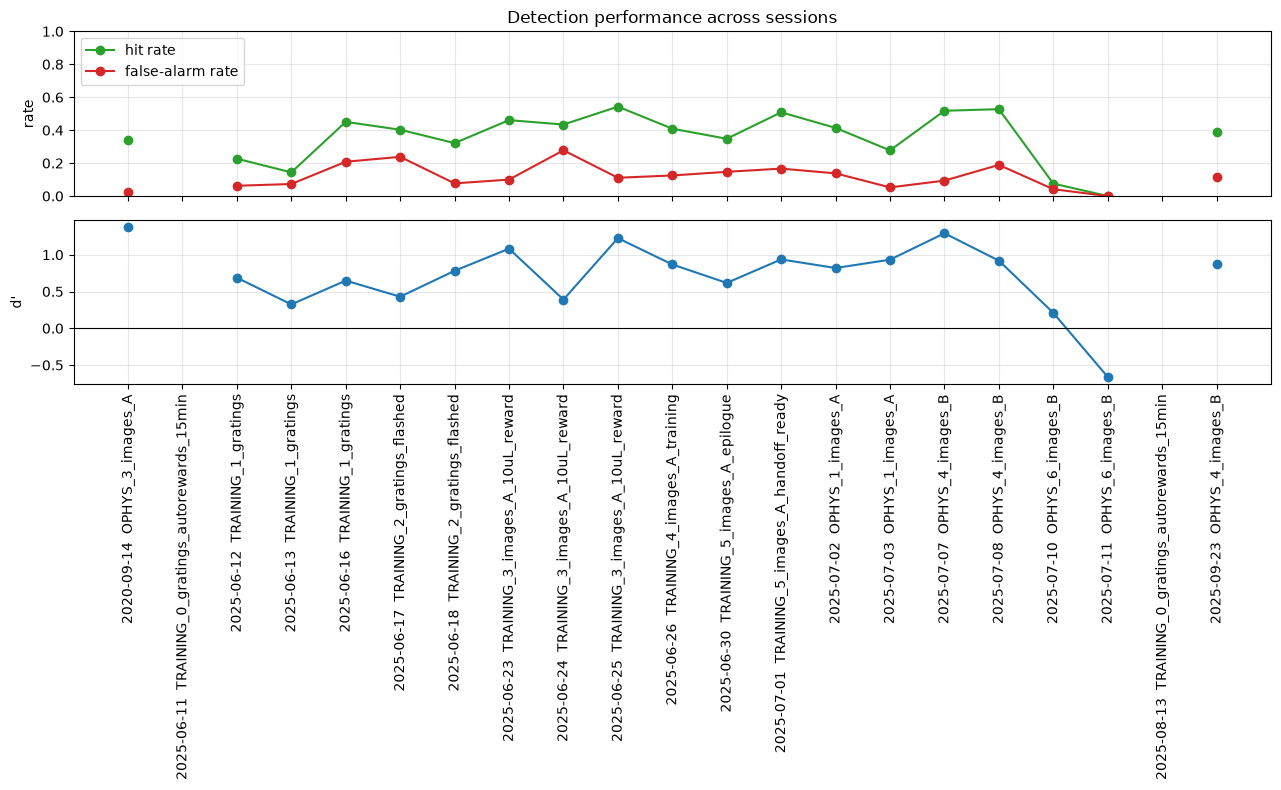

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.plot(x, metrics['hit_rate'], 'o-', label='hit rate', color='tab:green')
ax.plot(x, metrics['false_alarm_rate'], 'o-', label='false-alarm rate',
        color='tab:red')
ax.set_ylabel('rate')
ax.set_ylim(0, 1)
ax.legend(loc='upper left')
ax.set_title('Detection performance across sessions')
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(x, metrics['dprime'], 'o-', color='tab:blue')
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel("d'")
ax.grid(alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)
fig.tight_layout()
plt.show()

### 2. Trial-outcome composition
Stacked counts of hit / miss / false-alarm / correct-reject / aborted per session.

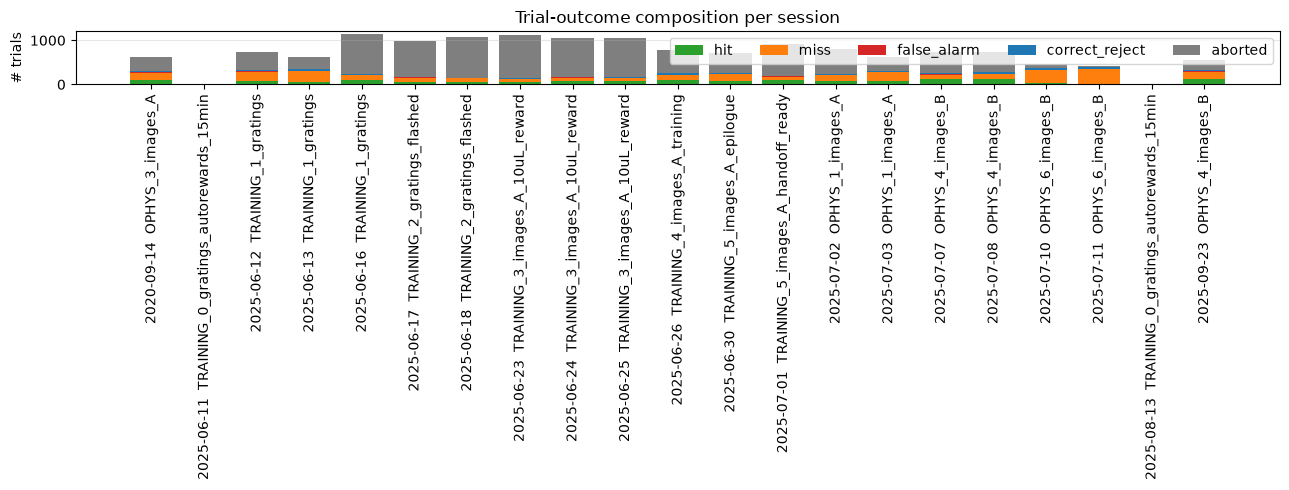

In [17]:
outcome_cols = ['n_hit', 'n_miss', 'n_false_alarm', 'n_correct_reject',
                'n_aborted']
outcome_cols = [c for c in outcome_cols if c in metrics.columns]
colors = ['tab:green', 'tab:orange', 'tab:red', 'tab:blue', 'tab:gray']

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(metrics))
for c, col in zip(outcome_cols, colors):
    ax.bar(x, metrics[c], bottom=bottom, label=c.replace('n_', ''), color=col)
    bottom += metrics[c].fillna(0).values
ax.set_ylabel('# trials')
ax.set_title('Trial-outcome composition per session')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)
ax.legend(loc='upper right', ncol=5)
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
plt.show()

### 3. Lick composition
Counts of each lick classification, stacked per session.

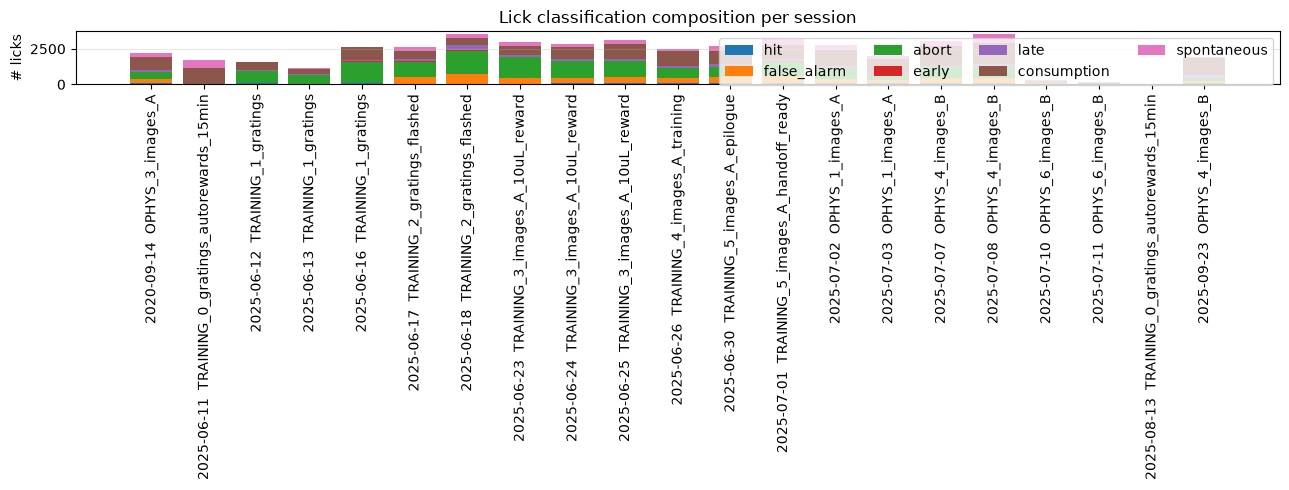

In [18]:
lick_cols = [c for c in metrics.columns
             if c.startswith('n_lick_') and c != 'n_lick_bouts']

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(metrics))
cmap = plt.get_cmap('tab10')
for i, c in enumerate(lick_cols):
    ax.bar(x, metrics[c], bottom=bottom,
           label=c.replace('n_lick_', ''), color=cmap(i % 10))
    bottom += metrics[c].fillna(0).values
ax.set_ylabel('# licks')
ax.set_title('Lick classification composition per session')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)
ax.legend(loc='upper right', ncol=4)
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
plt.show()

### 4. Rewards and reward volume

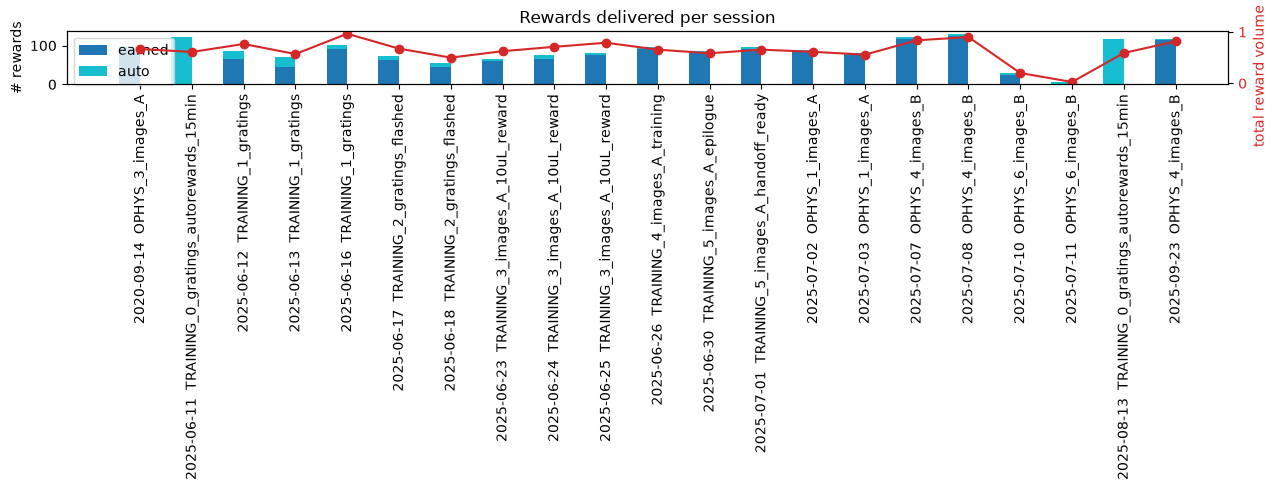

In [19]:
fig, ax1 = plt.subplots(figsize=(13, 5))
w = 0.4
if {'n_earned_rewards', 'n_auto_rewards'}.issubset(metrics.columns):
    ax1.bar(x - w / 2, metrics['n_earned_rewards'], width=w,
            label='earned', color='tab:blue')
    ax1.bar(x - w / 2, metrics['n_auto_rewards'],
            bottom=metrics['n_earned_rewards'].fillna(0), width=w,
            label='auto', color='tab:cyan')
else:
    ax1.bar(x - w / 2, metrics['n_rewards'], width=w, label='rewards',
            color='tab:blue')
ax1.set_ylabel('# rewards')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=90)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(x, metrics['total_reward_volume_ml'], 'o-', color='tab:red',
         label='total volume (mL)')
ax2.set_ylabel('total reward volume (mL)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax1.set_title('Rewards delivered per session')
fig.tight_layout()
plt.show()

### 5. Stimulus changes vs omissions

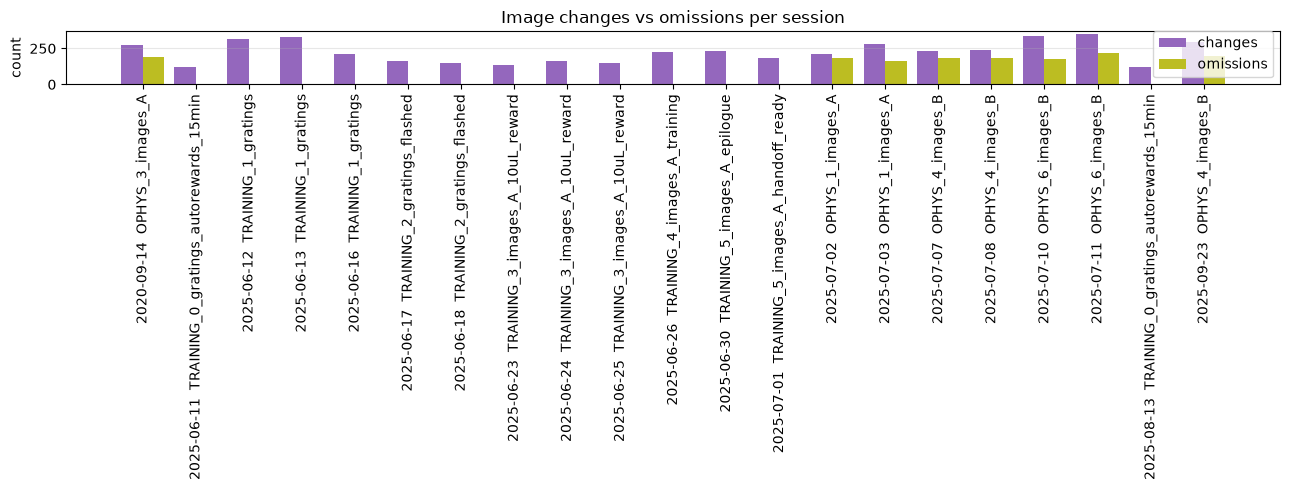

In [20]:
fig, ax = plt.subplots(figsize=(13, 5))
w = 0.4
ax.bar(x - w / 2, metrics['n_image_changes'], width=w, label='changes',
       color='tab:purple')
ax.bar(x + w / 2, metrics['n_image_omissions'], width=w, label='omissions',
       color='tab:olive')
ax.set_ylabel('count')
ax.set_title('Image changes vs omissions per session')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)
ax.legend()
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
plt.show()

### 6. Running speed (mean ± std)

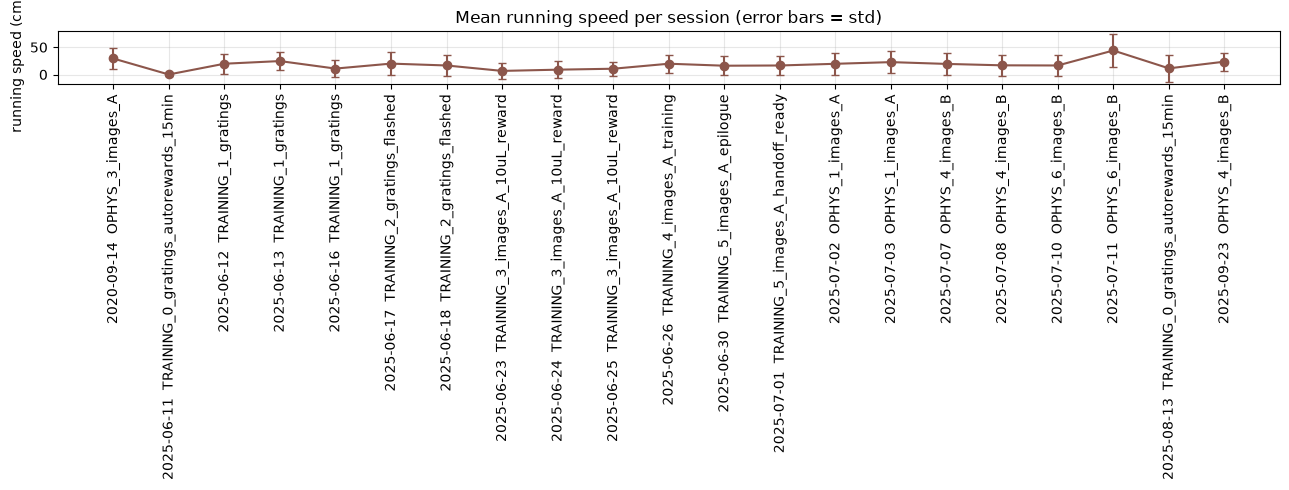

In [21]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.errorbar(x, metrics['running_speed_mean'],
            yerr=metrics['running_speed_std'], fmt='o-', capsize=3,
            color='tab:brown')
ax.set_ylabel('running speed (cm/s)')
ax.set_title('Mean running speed per session (error bars = std)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 7. Metric correlations
Quick correlation heatmap over the main numeric metrics to spot relationships
(e.g. does running speed track engagement / d-prime?).

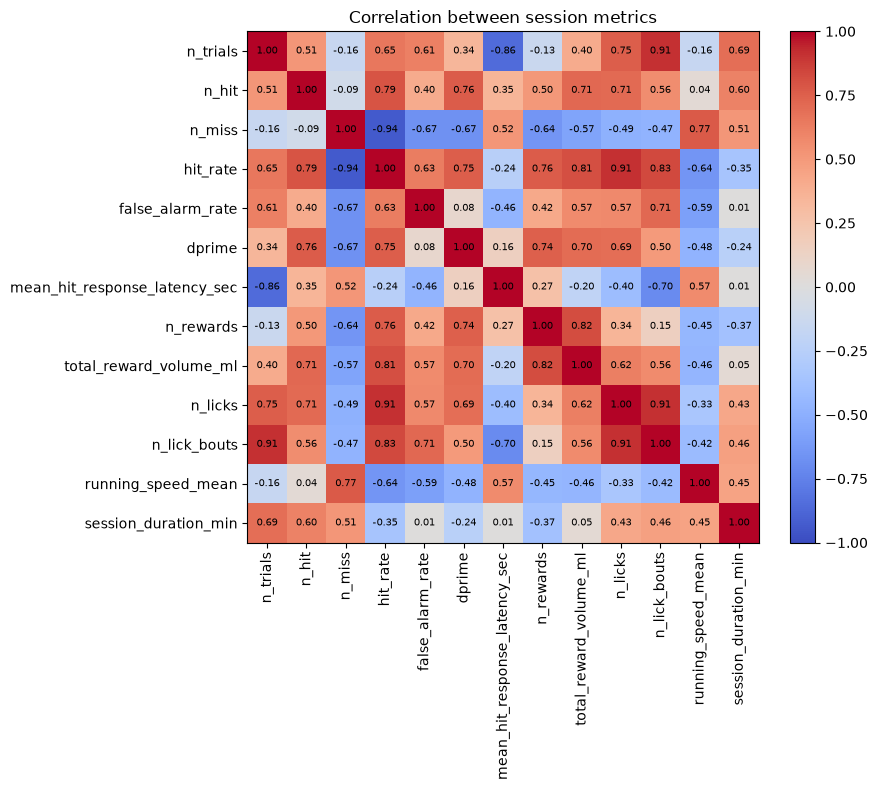

In [22]:
corr_cols = ['n_trials', 'n_hit', 'n_miss', 'hit_rate', 'false_alarm_rate',
             'dprime', 'mean_hit_response_latency_sec', 'n_rewards',
             'total_reward_volume_ml', 'n_licks', 'n_lick_bouts',
             'running_speed_mean', 'session_duration_min']
corr_cols = [c for c in corr_cols if c in metrics.columns]
corr = metrics[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='black', fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlation between session metrics')
fig.tight_layout()
plt.show()